In [7]:
"""
Letter decoding with mean‐template classifiers + cross‐session alignment.

Pipeline:
1) Load and precompute shared metadata (letters, sessions, windows).
2) For each bootstrap/permutation:
   a) Build session dictionaries expected by `compute_session_alignment`.
   b) Align sessions into a common subspace.
   c) Project trials and run mean‐template decoding in sliding time windows.
3) Aggregate across permutations and save per‐letter time×time decoding maps.
4) Perform cluster‐based permutation tests and plot significance overlays.

NOTE: This file adds comments and light structure only; algorithmic behavior
remains the same. Look for "TODO" tags on potential issues.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import pickle
import glob
import sys

# Make local code importable (expects Code/compute_session_alignment.py)
sys.path.append('./Code/')
import compute_session_alignment

from collections import Counter
from joblib import Parallel, delayed

# ---------------------------------------------------------------------
# Decoders: mean‐template variants
# ---------------------------------------------------------------------
def letter_decoding_mean(x_train, x_test, y_train, y_test, shuffle=False):
    """
    Mean‐template decoding that compares per‐class mean TEST activity to
    per‐class mean TRAIN templates using cosine similarity, but counts
    accuracy at the **class‐mean** level (i.e., 1 correct per class).

    Args
    ----
    x_train, x_test : array (trials × time × features) BEFORE windowing.
    y_train, y_test : array (trials,) with discrete class labels.
    shuffle         : bool, if True shuffles y labels for a null/control.

    Returns
    -------
    score_matrix : (n_win × n_win) array of counts (not normalized).
                   Entry (ti, tj) = number of classes correctly predicted
                   when training a template at window ti and testing on
                   class means at window tj.
    n_classes    : int, number of unique classes present in training labels.
    """
    
    n_win = len(window_ranges)
    score_matrix = np.zeros((n_win, n_win))

    # Copy/alias labels (already integers/strings)
    y_train_encoded = y_train
    y_test_encoded  = y_test
    class_labels    = [0,1] #np.unique(y_train_encoded)

    # Average activity in sliding windows and baseline‐correct by FIX bins
    #print((x_train.shape,x_test.shape),flush=True)
    xTTrain_all = [np.mean(x_train[:, start:end, :], axis=1) #- np.mean(x_train[:, 0:4, :], axis=1)
                   for (start, end) in window_ranges]
    xTTest_all  = [np.mean(x_test[:, start:end, :], axis=1)  #- np.mean(x_test[:, 0:4, :], axis=1)
                   for (start, end) in window_ranges]

    if shuffle:
        # Shuffle labels independently for train/test for a conservative null
        np.random.shuffle(y_train_encoded)
        np.random.shuffle(y_test_encoded)

    all_templates = []  # keep templates from each TRAIN window (for inspection)
    for ti, xTTrain in enumerate(xTTrain_all):
        for tj, xTTest in enumerate(xTTest_all):
            if(ti==tj):
                # --- TRAIN: build one mean template per class (in window ti)
                templates = []
                for c in class_labels:
                    class_indices = np.where(y_train_encoded == c)[0]
                    template = np.mean(xTTrain[class_indices], axis=0)
                    templates.append(template)
                templates = np.array(templates)  # (n_classes × n_features)

                if tj == 0:
                    all_templates.append(templates)

                # --- TEST: compare per‐class MEAN test activity to templates
                correct = 0
                for c_idx, c in enumerate(class_labels):
                    test_indices = np.where(y_test_encoded == c)[0]
                    if len(test_indices) == 0:
                        continue

                    # mean vector for THIS class/window
                    test_vec = np.mean(xTTest[test_indices], axis=0)

                    # Cosine similarity to each template -> scalars
                    corrs = [
                        float(np.dot(test_vec, tpl) / (np.linalg.norm(test_vec) * np.linalg.norm(tpl) + 1e-8))
                        for tpl in templates
                    ]

                    # tie-break
                    if len(corrs) == 2 and np.isclose(corrs[0], corrs[1]):
                        predicted_class_idx = np.random.choice([0, 1])
                    else:
                        predicted_class_idx = int(np.argmax(corrs))

                    predicted_class = class_labels[predicted_class_idx]
                    if predicted_class == c:
                        correct += 1
                        

            score_matrix[ti, tj] = correct  # raw count (not %)
            
    return score_matrix, 2, #len(class_labels)

In [8]:
units          = np.load('../Data/units.npy',allow_pickle=True)
completeBinned = np.load('../Data/binned.npy', allow_pickle=True)
letters        = np.load('../Data/letters.npy')
subj_ses       = np.load('../Data/subjs_sep.npy',allow_pickle=True)

In [9]:
from copy import deepcopy
NPC_TO_ALIGN = 5
# ---------------------------------------------------------------------
# Shared/static variables (loaded once)
# ---------------------------------------------------------------------
# NOTE: The following variables are referenced later. Make sure they are
# defined prior to calling functions that use them.

# Load all data (paths assume ../Data/ exists)
probes         = np.load('../Data/probes.npy')
subj           = np.load('../Data/subjs.npy')
subj_ses       = np.load('../Data/subjs_sep.npy', allow_pickle=True)
inout          = np.load('../Data/in.npy')
letters        = np.load('../Data/letters.npy')
letters_ses    = np.load('../Data/letters_sep.npy', allow_pickle=True)
probes_ses     = np.load('../Data/probes_sep.npy', allow_pickle=True)
units          = np.load('../Data/units.npy',allow_pickle=True)

# Subject/session metadata
sses          = [s[0] for s in subj_ses]
uniqueSub     = np.unique(sses)

# Letters (exclude rarely used or unwanted letters)
uniqueLetters = np.array([p for p in np.unique(letters) if p not in ['Q', 'W', 'X']])
n_labels      = len(uniqueLetters)

# Sliding windows: 4 bins wide, sliding by 1 bin (29 positions)
window_ranges = [(i, i + 1) for i in range(16)]

# ---------------------------------------------------------------------
# One permutation "trial": align, project, decode (for one letter)
# ---------------------------------------------------------------------
t1 = 2
t2 = 16
def single_trial(ktrial, letter_index):
    retry = 0 
    ok = False
    while not ok:
        maskSub = [subj_ses[i][0]!=outSub for i in range(len(subj_ses))]
        completeBinned = np.load('../Data/binned.npy', allow_pickle=True)
        completeBinned = completeBinned[maskSub]
        #Counter(subj)

        data = []
        train_test_labels = []

        Y      = [np.array([[1 if u in letterString else 0 for u in uniqueLetters] for letterString in ls], dtype=int)
                 for ls in letters_ses[maskSub]]
        
        Yprobe = [np.array([[1 if u in letterString else 0 for u in uniqueLetters] for letterString in ls], dtype=int)
                 for ls in probes_ses[maskSub]]
         
        maskSET_TEST  = [np.sum(yi,axis=1)>0 for yi in Y]
        maskSET_TRAIN = [np.sum(yi,axis=1)>0 for yi in Y]
        
        #maskSET_TEST  = [np.sum(yi*yp,axis=1)>=0 for (yi,yp) in zip(Y,Yprobe)]
        #maskSET_TRAIN = [np.sum(yi*yp,axis=1)>=0 for (yi,yp) in zip(Y,Yprobe)]
        #print(maskSET_TEST,flush=True)
        
        units =  np.load('../Data/units.npy', allow_pickle=True)
        units = units[maskSub]

        all_maskU = []
        newcompleteBinned = []
        newY = []
        newMaskSET_TEST  = []
        newMaskSET_TRAIN = []
        for i in range(len(completeBinned)):
            
            maskU = [list(np.where(['R' in ui for ui in units[i][0]])[0])+
            #list(np.where(['AHL' in ui for ui in units[i][0]])[0])+
            #list(np.where(['PHR' in ui for ui in units[i][0]])[0])+
            list(np.where(['L' in ui for ui in units[i][0]])[0])][0]
            
            
            bst = completeBinned[i]
            #print(bst.shape,flush=True)
            #print(maskU,flush=True)
            
            bst = bst[:,maskU]
            bst = np.transpose(bst, (1, 2, 0))
            if len(bst) >= NPC_TO_ALIGN:
                newcompleteBinned.append(completeBinned[i])
                newY.append(Y[i])
                newMaskSET_TEST.append(maskSET_TEST[i])
                newMaskSET_TRAIN.append(maskSET_TRAIN[i])
                tt_label  = np.random.uniform(0, 1, len(bst[0][0])) > 0.5
                #tt_label = np.zeros(len(bst[0][0]))
                #tt_label[np.random.choice(np.arange(len(tt_label)),
                #                          size=1,
                #                          replace=False)] = 1

                condition = Y[i][:, letter_index]

                mask    = np.logical_and(tt_label == 0,condition>-1)
                timeB   = np.arange(len(bst[0])) * 0.250
                session = {
                    'response' : bst[:,:,mask],#bst[:, :, tt_label == 0],
                    'condition': condition[mask],#condition[tt_label == 0],
                    'time'     : timeB
                }
                data.append(session)
                all_maskU.append(maskU)
                train_test_labels.append(tt_label)


        pars = {'alignment': {'nPCs_align': NPC_TO_ALIGN, 'cond_contrast': (1, 0)}, 'align_proj': {'condition_vars': []}}

        D_align, D_cond_avg_proj_align, align_stats = compute_session_alignment.compute_session_alignment_CONTRAST_2BIAS(data, [], pars,t1,t2)

        Z_align = deepcopy(D_align)
        #print(len(all_maskU),len(train_test_labels),len(newcompleteBinned),len(D_align),newcompleteBinned[0].shape,flush=True)
        X = np.concatenate([Z_align[i]['response'] for i in range(len(Z_align))], axis=2)
        #X = X[accepted_components]
        projected_X = [
            np.transpose(newcompleteBinned[sesID][:,all_maskU[sesID]], (0, 2, 1)) @ D_align[sesID]['U'] + D_align[sesID]['bias'] #[:, accepted_components]
            for sesID in range(len(newcompleteBinned))
        ]

        #print(len(projected_X),flush=True)
        X_train = [projected_X[i][np.logical_and(train_test_labels[i] == 0, newMaskSET_TRAIN[i])] for i in range(len(train_test_labels))]
        X_test  = [projected_X[i][np.logical_and(train_test_labels[i] == 1, newMaskSET_TEST[i])] for i in range(len(train_test_labels))]
        Y_train = [newY[i][np.logical_and(train_test_labels[i] == 0, newMaskSET_TRAIN[i]), letter_index] for i in range(len(train_test_labels))]
        Y_test  = [newY[i][np.logical_and(train_test_labels[i] == 1, newMaskSET_TEST[i]), letter_index] for i in range(len(train_test_labels))]
        #Y_probe_test  = [Yprobe[i][train_test_labels[i] == 1, letter_index] for i in range(len(train_test_labels))]

        X_train = np.concatenate(X_train, axis=0)
        X_test  = np.concatenate(X_test, axis=0)
        Y_train = np.concatenate(Y_train, axis=0)
        Y_test  = np.concatenate(Y_test, axis=0)
        
        if( (np.sign(np.mean(X_train[Y_train==1,t1:t2]))*np.sign(np.mean(X_train[Y_train==0,t1:t2])))<0 ):
            ok = True
        else:
            print('retry attempt: ',retry,flush=True)
            retry += 1
    
    
    MW,SUM_IT = letter_decoding_mean(
            X_train,
            X_test,
            Y_train,
            Y_test,
            shuffle=False
        )

    #return [D_align[sesID]['U'] + D_align[sesID]['bias'] for sesID in range(len(completeBinned))]
    return MW,SUM_IT

In [10]:
np.unique(subj)

array([40, 43, 44, 45, 47, 53, 57, 58, 61, 63, 64])

['B' 'C' 'D' 'F' 'G' 'H' 'K' 'L' 'N' 'P' 'R' 'S' 'T' 'V' 'Z']


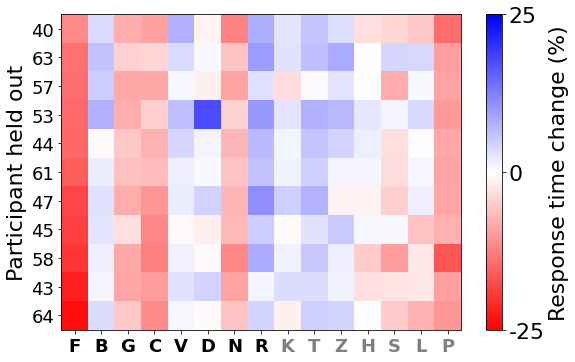

In [11]:
import numpy as np
import matplotlib.pyplot as plt

units = np.load('../Data/units.npy',allow_pickle=True)
# reaction time
reaction = np.load('../Data/reaction.npy',allow_pickle=True)
letters  = np.load('../Data/letters_sep.npy',allow_pickle=True)
probes   = np.load('../Data/probes_sep.npy',allow_pickle=True)
uniqueLetters = np.array([p for p in np.unique(np.concatenate(letters)) if p not in ['Q', 'W', 'X']])
print(uniqueLetters)

setsize  = [
           np.array([np.sum([1 if u in letterString else 0 for u in uniqueLetters]) for letterString in ls],dtype=int)
           for ls in letters]

subj = np.load('../Data/subjs_sep.npy',allow_pickle=True)
subj = [s[0] for s in subj]
info = np.load('../Data/trial_corrInfo.npy',allow_pickle=True)
uniqueSub  = np.unique(subj)
sub_list   = list(uniqueSub) + [0]   # leave-one-out + no-0 baseline
n_letters  = len(uniqueLetters)      # should be 15

all_m = {}   # stores m for each subOut
L = 15
# ----------------------------------------------------------
# FUNCTION: compute m vector for one subOut
# ----------------------------------------------------------
def compute_m_for_subout(subOut):

    setREF  = [4, 6, 8]
    respREF = [52]

    # -----------------------------
    # First condition: respREF = [52]
    # -----------------------------
    corr_letter_all = []
    for u in uniqueLetters:
        corr_letter = []
        for s in np.unique(subj):
            if s != subOut:

                mask       = np.where(subj == s)[0]
                probe_subj = np.concatenate(probes[mask], axis=0)
                info_cat   = np.concatenate(info[mask], axis=0)

                corr_subj  = info_cat[:, -1]
                corr_subj  = corr_subj[np.where(np.logical_and(
                    np.logical_and(info_cat[:, 1],
                                   [m in respREF for m in info_cat[:, 3]]),
                    [m in setREF  for m in info_cat[:, 0]])
                )[0]]

                resp  = info_cat[info_cat[:,1] == True, 3]
                setR  = info_cat[info_cat[:,1] == True, 0]

                probe_subj = probe_subj[
                    np.logical_and([r in respREF for r in resp],
                                   [r in setREF  for r in setR])
                ]
                mask_u = np.where(probe_subj == u)[0]
                corr_letter.extend(corr_subj[mask_u])

        corr_letter_all.append(corr_letter)

    corr_letter_all = np.array(corr_letter_all, dtype=object)

    # median correlation for respREF = [52]
    m52 = [np.median(corr_letter_all[i]) for i in range(n_letters)]

    # ----------------------------------------------------------
    # Second condition: respREF = [51]
    # ----------------------------------------------------------
    respREF = [51]
    corr_letter_all = []
    for u in uniqueLetters:
        corr_letter = []
        for s in np.unique(subj):
            if s != subOut:

                mask       = np.where(subj == s)[0]
                probe_subj = np.concatenate(probes[mask], axis=0)
                info_cat   = np.concatenate(info[mask], axis=0)

                corr_subj  = info_cat[:, -1]
                corr_subj  = corr_subj[np.where(np.logical_and(
                    np.logical_and(info_cat[:, 1],
                                   [m in respREF for m in info_cat[:, 3]]),
                    [m in setREF  for m in info_cat[:, 0]])
                )[0]]

                resp  = info_cat[info_cat[:,1] == True, 3]
                setR  = info_cat[info_cat[:,1] == True, 0]

                probe_subj = probe_subj[
                    np.logical_and([r in respREF for r in resp],
                                   [r in setREF  for r in setR])
                ]
                mask_u = np.where(probe_subj == u)[0]
                corr_letter.extend(corr_subj[mask_u])

        corr_letter_all.append(corr_letter)

    corr_letter_all = np.array(corr_letter_all, dtype=object)

    # median correlation for respREF = [51]
    m51 = [np.median(corr_letter_all[i]) for i in range(n_letters)]

    # ----------------------------------------------------------
    # Final m vector (fractional response-time change)
    # ----------------------------------------------------------
    m = (np.array(m51) - np.array(m52)) / np.array(m52)

    return m


# ----------------------------------------------------------
# Compute m for all subOut values
# ----------------------------------------------------------
for subOut in sub_list:
    all_m[subOut] = compute_m_for_subout(subOut)


# ----------------------------------------------------------
# Build percentual change matrix relative to the no-subject-removed baseline
# ----------------------------------------------------------
m_no0 = all_m[0]   # baseline vector

change_matrix = np.zeros((len(sub_list), n_letters))
row_labels    = []

for i, subOut in enumerate(sub_list):

    if subOut == 0:
        change_matrix[i, :] = 0
        row_labels.append("no0")
    else:
        change_matrix[i, :] = all_m[subOut] #((all_m[subOut] - m_no0)/np.abs(m_no0))
        row_labels.append(f"no{subOut}")

# -----------------------------------------------------------
# 1) Compute GLOBAL letter ordering
# -----------------------------------------------------------
global_letter_acc = []
T1 = 2
T2 = 16
T = T2-T1
for k in range(50):
    al = []
    all_L = np.load(f'../Results/single_letter_{k}.npy')
    for letter_index in range(L):
        al.append(np.diag(all_L[letter_index]))
    al = np.array(al)
    global_letter_acc.append(al)

global_letter_acc = np.array(global_letter_acc)  # shape: (50, L, n_times)

# Compute global last-step accuracy like your code
global_last = np.array([
    np.cumsum(global_letter_acc[:, i, T1:T2], axis=-1)[:, -1] / T
    for i in range(L)
])  # shape: (L, 50)

# Mean global decoding accuracy per letter                     ### NEW
global_mean_per_letter = np.median(global_last, axis=1)          # shape: (L,)  ### NEW

# Sorting order (descending)
sort_idx = np.argsort(np.median(global_last, axis=1))[::-1]
#sort_idx = np.argsort(m_no0)

# -----------------------------------------------------------
# 5) Plot heatmap of percentage point difference
# -----------------------------------------------------------
L = 15
change_matrix = change_matrix[:-1, sort_idx]  # same as before

sortF = np.argsort(change_matrix[:,0])[::-1]

# If you want to plot ranks instead of raw changes:
change_2 = change_matrix[sortF] #rank_matrix

plt.rcParams.update({'font.size': 22})
fig, ax = plt.subplots(figsize=(1 + L * 0.5, 1.1 + len(uniqueSub) * 0.4))

sorted_letters = uniqueLetters[sort_idx]
im = ax.imshow(change_2, aspect='auto', cmap='bwr_r',vmin=-0.25,vmax=0.25)

# (Optional) you might still want this based on raw changes, not ranks:
fano_per_letter = np.mean(np.abs(change_matrix), axis=0)

ax.set_xticks(np.arange(L))
ax.set_xticklabels(sorted_letters, rotation=0, fontsize=18)

ax.set_yticks(np.arange(len(uniqueSub)))
#ax.set_yticklabels(np.arange(1,len(uniqueSub)+1), fontsize=18)
ax.set_yticklabels(uniqueSub[sortF], fontsize=18)

ax.set_ylabel('Participant held out')

cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Response time change (%)')
cbar.set_ticks([-0.25, 0, 0.25])          # numeric tick positions
cbar.set_ticklabels(['-25', '0', '25']) # what to display

setLETTER = ['F','B','C','G','V','D','N','R']
# Make selected letters bold black, others bold gray
for tick, letter in zip(ax.get_xticklabels(), sorted_letters):
    if letter in setLETTER:
        tick.set_color('black')
    else:
        tick.set_color('gray')
    tick.set_fontweight('bold')

plt.tight_layout()
plt.savefig('resp_subj2_idx.svg', dpi=200)
plt.show()

Global letter order: ['F' 'B' 'G' 'C' 'V' 'D' 'N' 'R' 'K' 'T' 'Z' 'H' 'S' 'L' 'P']


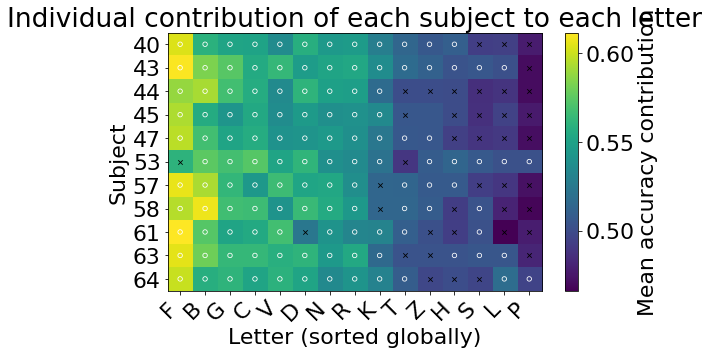

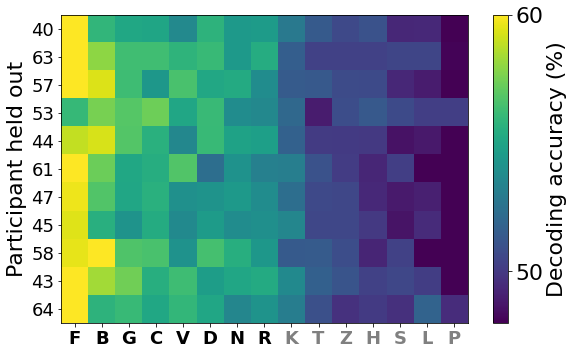

In [13]:


T1 = 2
T2 = 16
T = T2 - T1
n_runs = 20
L = 15

#data_shuf = [last_shuffle[i] for i in order]

import numpy as np
import matplotlib.pyplot as plt

target_letters = ['F','B','C','G','V','D','N','R']

# -----------------------------------------------------------
# 1) Compute GLOBAL letter ordering
# -----------------------------------------------------------
global_letter_acc = []
for k in range(50):
    al = []
    all_L = np.load(f'../Results/single_letter_{k}.npy')
    for letter_index in range(L):
        al.append(np.diag(all_L[letter_index]))
    al = np.array(al)
    global_letter_acc.append(al)

global_letter_acc = np.array(global_letter_acc)  # shape: (50, L, n_times)

# Compute global last-step accuracy like your code
global_last = np.array([
    np.cumsum(global_letter_acc[:, i, T1:T2], axis=-1)[:, -1] / T
    for i in range(L)
])  # shape: (L, 50)

# Mean global decoding accuracy per letter                     ### NEW
global_mean_per_letter = np.median(global_last, axis=1)          # shape: (L,)  ### NEW

# Sorting order (descending)
sort_idx = np.argsort(np.median(global_last, axis=1))[::-1]

print("Global letter order:", uniqueLetters[sort_idx])

# -----------------------------------------------------------
# 2) Compute subject-specific contributions
# -----------------------------------------------------------
sub_letter_contrib = []

for s in uniqueSub:
    letter_acc = []
    for k in range(n_runs):
        all_Letters = np.load(f'../Results/single_letter_noSub{s}_{k}.npy')

        al_real = []
        for letter_index in range(L):
            al_real.append(np.diag(all_Letters[letter_index]))
        al_real = np.array(al_real)
        letter_acc.append(al_real)

    letter_acc = np.array(letter_acc)  # (runs, L, time)

    last_true = np.array([
        np.cumsum(letter_acc[:, i, T1:T2], axis=-1)[:, -1] / T
        for i in range(L)
    ])

    sub_letter_contrib.append(np.median(last_true, axis=1))

sub_letter_contrib = np.array(sub_letter_contrib)  # (subjects, L)

# -----------------------------------------------------------
# 3) Apply GLOBAL letter sorting
# -----------------------------------------------------------
sub_letter_contrib = sub_letter_contrib[:, sort_idx]
sorted_letters = uniqueLetters[sort_idx]

# Global mean per letter, in the same sorted order            ### NEW
global_mean_sorted = global_mean_per_letter[sort_idx]         # shape: (L,)  ### NEW

# -----------------------------------------------------------
# 4) Plot heatmap
# -----------------------------------------------------------
fig, ax = plt.subplots(figsize=(1 + L * 0.5, 1 + len(uniqueSub) * 0.4))

im = ax.imshow(sub_letter_contrib, aspect='auto')

ax.set_xticks(np.arange(L))
ax.set_xticklabels(sorted_letters, rotation=45, ha='right')

ax.set_yticks(np.arange(len(uniqueSub)))
ax.set_yticklabels(uniqueSub)

ax.set_xlabel('Letter (sorted globally)')
ax.set_ylabel('Subject')
ax.set_title('Individual contribution of each subject to each letter')

cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Mean accuracy contribution')

# -----------------------------------------------------------
# 5) Overlay info: higher/lower than GLOBAL decoding mean     ### NEW
# -----------------------------------------------------------
n_subj, n_letters = sub_letter_contrib.shape

# Broadcast global mean per letter over subjects
baseline = global_mean_sorted[None, :]   # shape: (1, L)

higher_than_global = sub_letter_contrib > baseline
lower_than_global  = sub_letter_contrib < baseline

ys_high, xs_high = np.where(higher_than_global)
ys_low,  xs_low  = np.where(lower_than_global)

# Above global mean: circle marker
ax.scatter(
    xs_high, ys_high,
    marker='o',
    s=20,
    facecolors='none',
    edgecolors='white',
    linewidths=0.8,
    label='Above global mean'
)

# Below global mean: x marker
ax.scatter(
    xs_low, ys_low,
    marker='x',
    s=20,
    color='black',
    linewidths=0.8,
    label='Below global mean'
)

#ax.legend(loc='upper right', fontsize=8, frameon=True)

plt.tight_layout()
plt.show()

# -----------------------------------------------------------
# 4) Compute percentage point difference (subject - global)
# -----------------------------------------------------------
baseline = global_mean_sorted[None, :]   # shape: (1, L), broadcast over subjects

# difference in percentage points (assuming accuracies are between 0 and 1)
diff_pp = sub_letter_contrib[sortF]  # shape: (n_subj, L)

# Optional: symmetric color range around 0 for nicer visualization
vmax = np.max(np.abs(diff_pp))

# -----------------------------------------------------------
# 5) Plot heatmap of percentage point difference
# -----------------------------------------------------------
plt.rcParams.update({'font.size': 22})
fig, ax = plt.subplots(figsize=(1 + L * 0.5, 1 + len(uniqueSub) * 0.4))

im = ax.imshow(diff_pp, aspect='auto', vmin=0.48, vmax=0.6)

ax.set_xticks(np.arange(L))
ax.set_xticklabels(sorted_letters, rotation=0, fontsize=18, fontweight='bold')

# ---- NEW: color x-axis letters depending on target_letters ----
for label, letter in zip(ax.get_xticklabels(), sorted_letters):
    if letter in target_letters:
        label.set_color('black')   # bold + black
    else:
        label.set_color('gray')    # bold + gray
# ---------------------------------------------------------------

ax.set_yticks(np.arange(len(uniqueSub)))
ax.set_yticklabels(uniqueSub[sortF], fontsize=18)
#ax.set_yticklabels(np.arange(1,len(uniqueSub)+1), fontsize=18)

ax.set_ylabel('Participant held out')

cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Decoding accuracy (%)')

# -----------------------------------------------------------
# 5b) Annotate cells where actual accuracy > 0.52
#     (using sub_letter_contrib, not diff_pp)
# -----------------------------------------------------------
threshold = 0.52 #np.percentile(np.array(data_shuf).flatten(),95)
mask = sub_letter_contrib > threshold   # boolean mask

ys, xs = np.where(mask)
'''
ax.scatter(
    xs, ys,
    s=50,
    marker='.',
    facecolors='black',
    edgecolors='none',
    linewidths=1.0
)
'''
cbar.set_ticks([0.6, 0.5])          # numeric tick positions
cbar.set_ticklabels(['60','50']) # what to display
plt.tight_layout()
plt.savefig('subject_out_idx2.svg', dpi=200)
plt.show()

In [7]:
sub_letter_contrib.shape

(11, 15)

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import kendalltau

# --------------------------------------------------------
# 1. Compute observed tau values and their median
# --------------------------------------------------------
observed_taus = np.array([
    kendalltau(global_mean_per_letter[sort_idx], diff_pp[p])[0]
    for p in range(len(diff_pp))
])

observed_median = np.median(observed_taus)

# --------------------------------------------------------
# 2. Build permutation-null distribution of medians
# --------------------------------------------------------
n_perm       = 5000
perm_medians = np.zeros(n_perm)

for i in range(n_perm):
    perm_diff = np.array([np.random.permutation(diff_pp[p]) for p in range(len(diff_pp))])
    perm_taus = np.array([
        kendalltau(global_mean_per_letter[sort_idx], perm_diff[p])[0]
        for p in range(len(diff_pp))
    ])
    perm_medians[i] = np.median(perm_taus)


In [10]:
observed_median

0.861253877644822

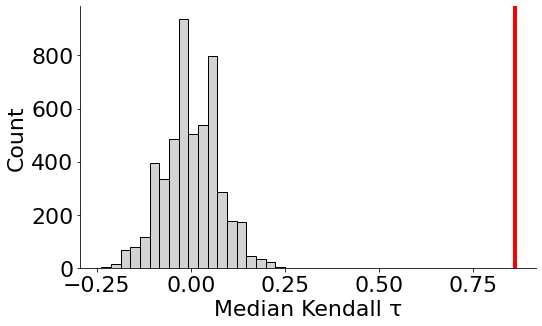

In [9]:
# --------------------------------------------------------
# 3. Plot histogram + red median line
# --------------------------------------------------------
fig,ax = plt.subplots(figsize=(8,5))
plt.hist(perm_medians, bins=20, color='lightgray', edgecolor='black')
plt.axvline(observed_median, color='red', linewidth=4, label=f'Observed median = {observed_median:.3f}')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.xlabel("Median Kendall τ")
plt.ylabel("Count")
plt.tight_layout()
plt.show()